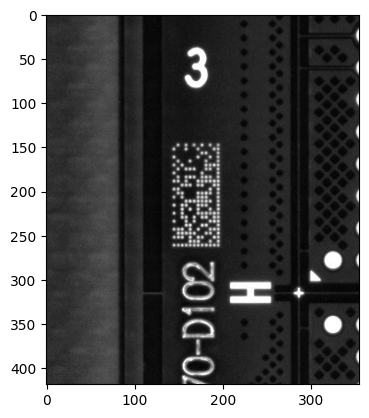

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

img = cv2.imread(r'D:\\Non_Documents\\Image Matrix\\200128837_102_0(0).jpg', cv2.IMREAD_GRAYSCALE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img = clahe.apply(img)

plt.imshow(img, cmap='gray')

True

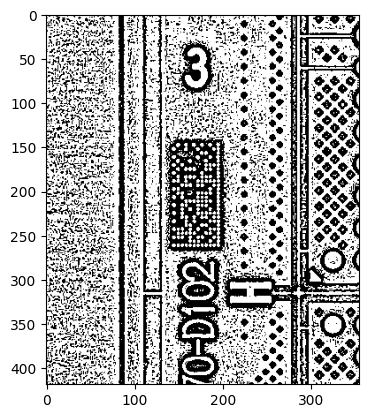

In [58]:
binary = cv2.adaptiveThreshold(
    img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)
plt.imshow(binary, cmap='gray')
cv2.imwrite(r'd:\\TEST\\binary_image.jpg', binary)

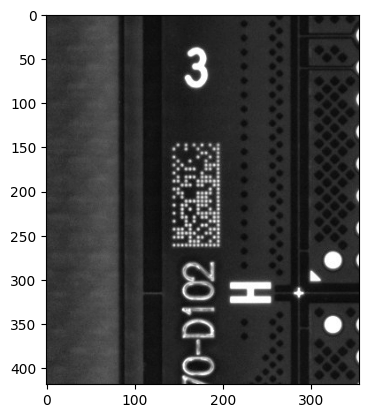

In [62]:
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 3. 시각화용 컬러 이미지
vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

plt.imshow(vis, cmap='gray')




In [ ]:
dot_count = 0

# 4. 컨투어 필터링 및 그리기
for cnt in contours:
    area = cv2.contourArea(cnt)
    if 2 < area < 15:  # 도트 면적 범위 제한
        perimeter = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * area / (perimeter * perimeter + 1e-5)  # 원형성

        if circularity > 0.6:  # 원 형태에 가까운 것만 선택
            dot_count += 1
            cv2.drawContours(vis, [cnt], -1, (0, 255, 0), 1)  # 초록색으로 윤곽선 그리기

print(f" 검출된 흰색 원 도트 수: {dot_count}")



[INFO] 검출된 흰색 원 도트 수: 0
